In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("startup_success_dataset.csv") 

# Preview
print(df.head())
print(df.info())

   funding_rounds  founder_experience_years  team_size  market_size_billion  \
0               4                        13         58            48.225483   
1               1                         6        221            31.532647   
2               3                         5        247             4.969722   
3               3                        14        229             3.084209   
4               1                        17        235            13.818188   

   product_traction_users  burn_rate_million  revenue_million investor_type  \
0                  594843          18.519211     1.483962e+06      tier2_vc   
1                  393020          14.298149     8.620568e+05      tier2_vc   
2                   27636          20.447567     9.726169e+04          none   
3                  235376           8.177417     1.145785e+06          none   
4                  391765           4.879792     8.608949e+05          none   

      sector founder_background      outcome  
0  

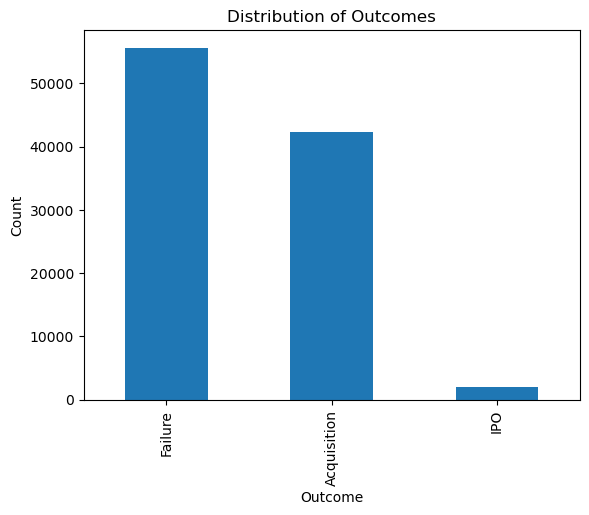

In [3]:
plt.figure()
df['outcome'].value_counts().plot(kind='bar')
plt.title("Distribution of Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

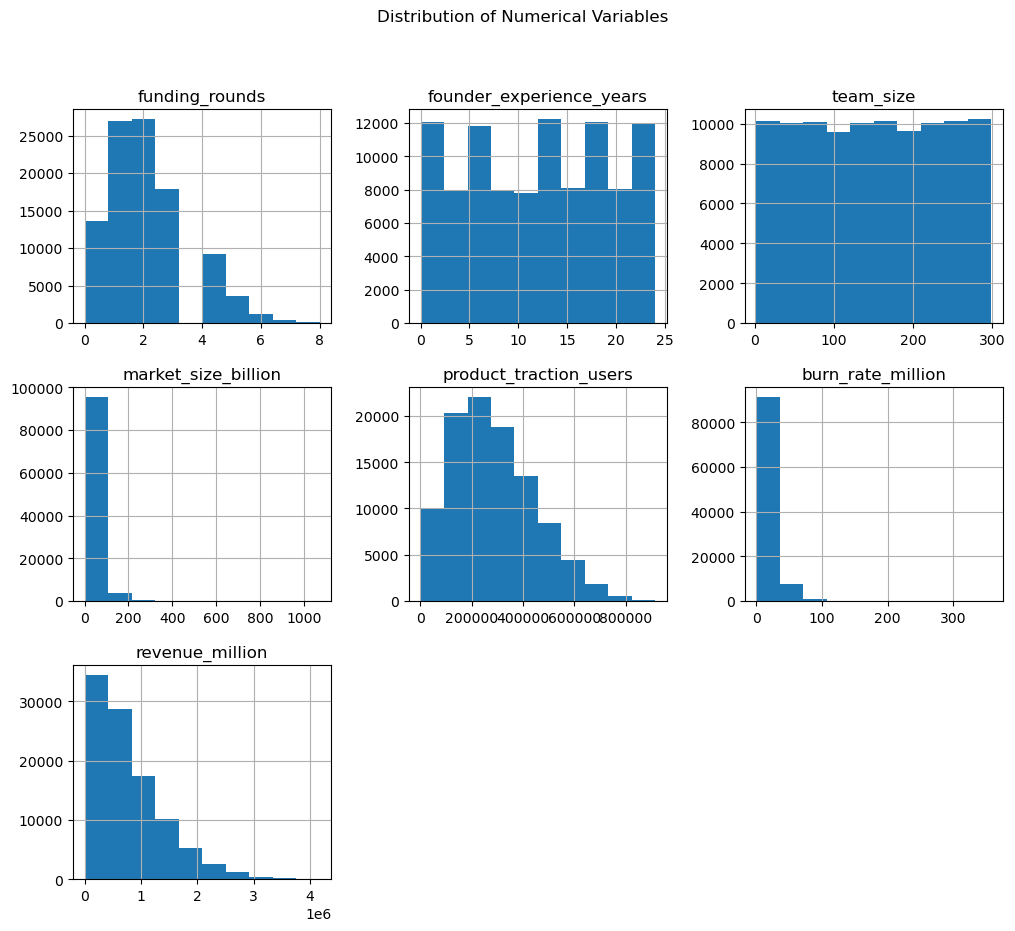

In [4]:
df.hist(figsize=(12,10))
plt.suptitle("Distribution of Numerical Variables")
plt.show()

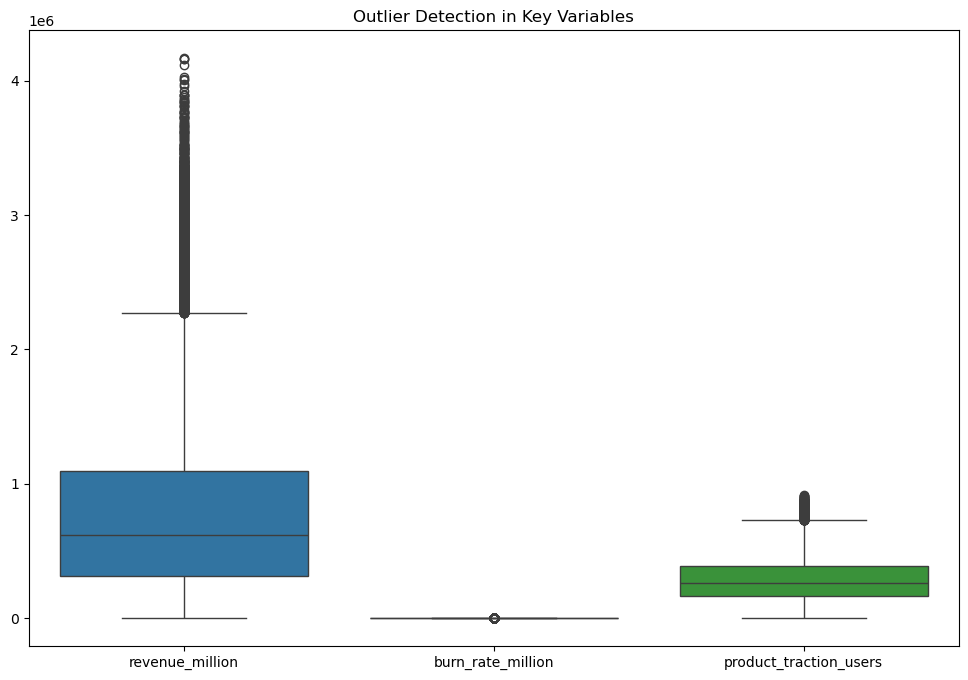

In [5]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.boxplot(data=df[['revenue_million','burn_rate_million','product_traction_users']])
plt.title("Outlier Detection in Key Variables")
plt.show()

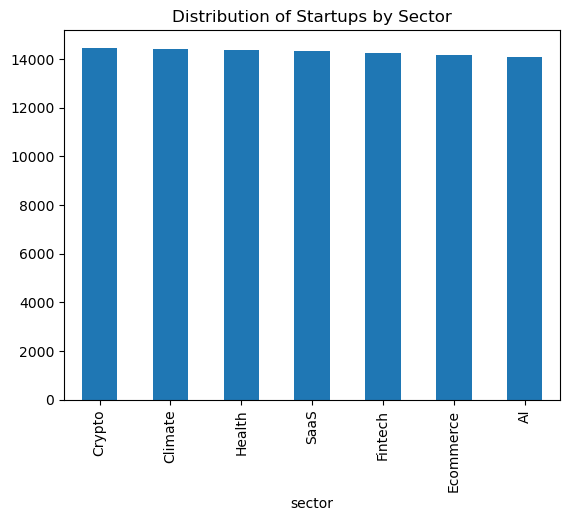

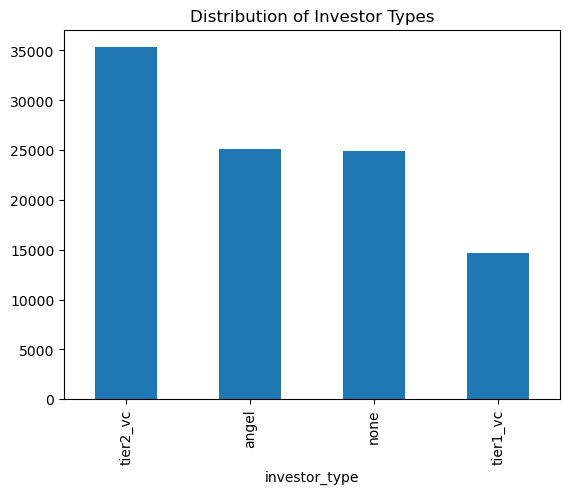

In [6]:
plt.figure()
df['sector'].value_counts().plot(kind='bar')
plt.title("Distribution of Startups by Sector")
plt.show()

plt.figure()
df['investor_type'].value_counts().plot(kind='bar')
plt.title("Distribution of Investor Types")
plt.show()

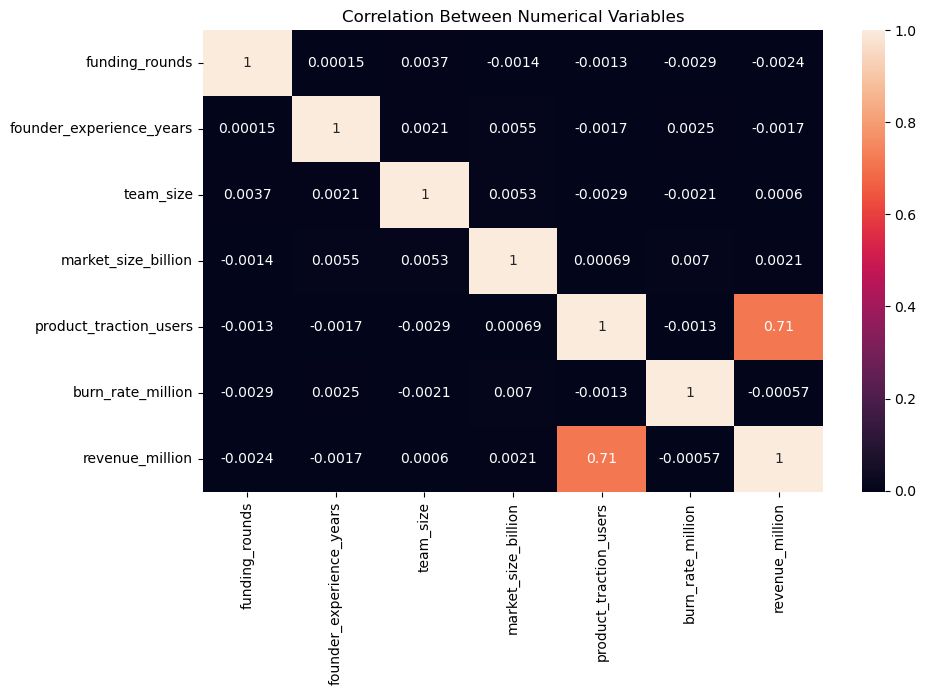

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Numerical Variables")
plt.show()

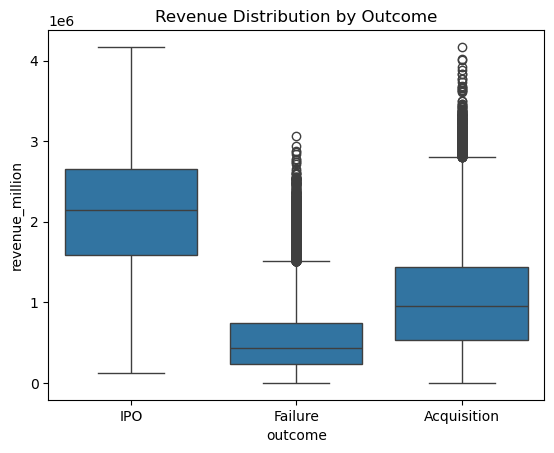

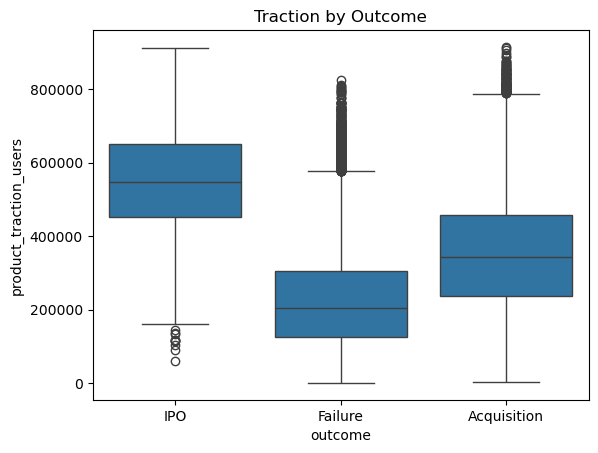

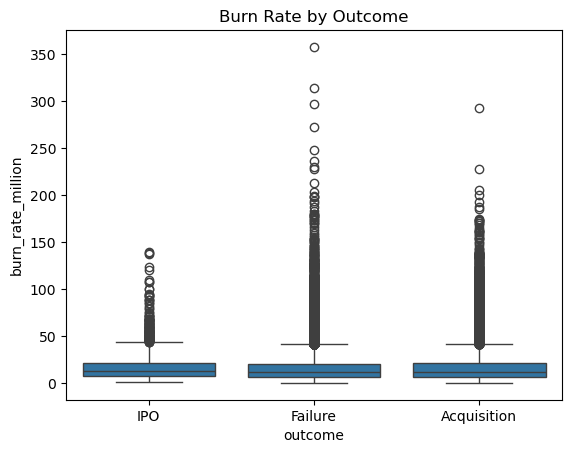

In [8]:
sns.boxplot(x='outcome', y='revenue_million', data=df)
plt.title("Revenue Distribution by Outcome")
plt.show()

sns.boxplot(x='outcome', y='product_traction_users', data=df)
plt.title("Traction by Outcome")
plt.show()

sns.boxplot(x='outcome', y='burn_rate_million', data=df)
plt.title("Burn Rate by Outcome")
plt.show()

In [9]:
df['log_revenue'] = np.log1p(df['revenue_million'])

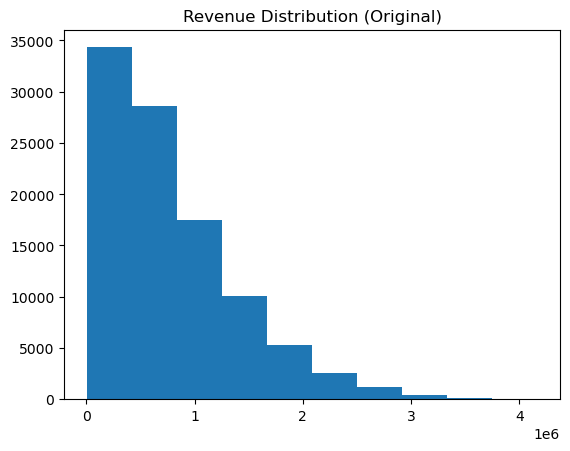

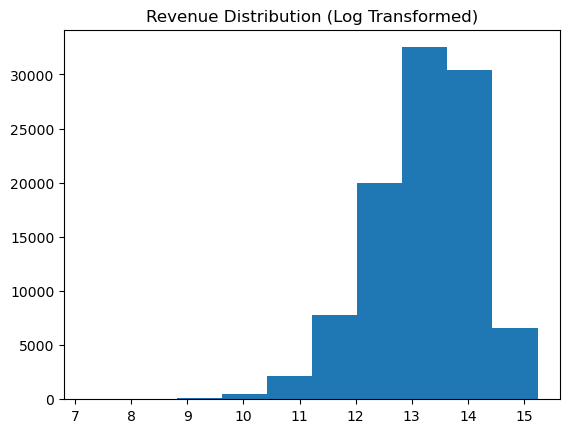

In [10]:
plt.figure()
plt.hist(df['revenue_million'])
plt.title("Revenue Distribution (Original)")
plt.show()

plt.figure()
plt.hist(df['log_revenue'])
plt.title("Revenue Distribution (Log Transformed)")
plt.show()

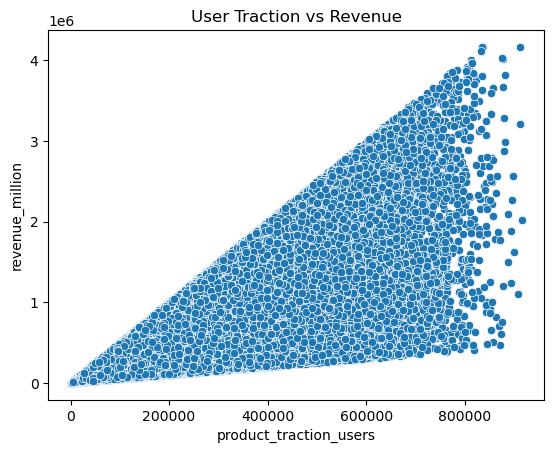

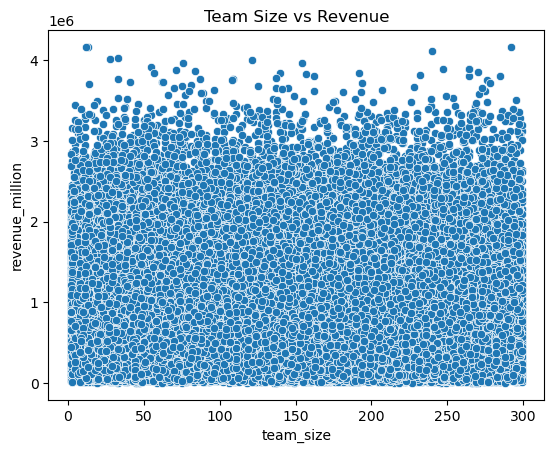

In [11]:
sns.scatterplot(x='product_traction_users', y='revenue_million', data=df)
plt.title("User Traction vs Revenue")
plt.show()

sns.scatterplot(x='team_size', y='revenue_million', data=df)
plt.title("Team Size vs Revenue")
plt.show()

In [12]:
cat_cols = ['investor_type', 'sector', 'founder_background']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['revenue_million', 'log_revenue', 'outcome'])
y = df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

preds_lr = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, preds_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_lr)))

R2 Score: 0.4893898613570208
RMSE: 0.6609056997369397


In [14]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

preds_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, preds_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_rf)))

R2 Score: 0.5723859034438046
RMSE: 0.604812540026539


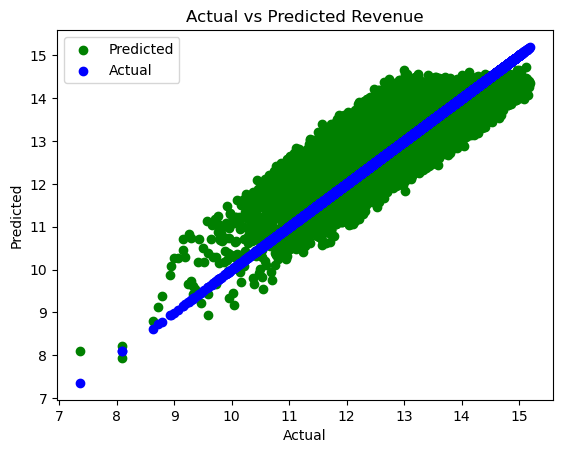

In [19]:
plt.figure()
plt.scatter(y_test, preds_rf, color="green", label="Predicted")
plt.scatter(y_test, y_test, color="blue", label="Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Revenue")
plt.legend()
plt.show()

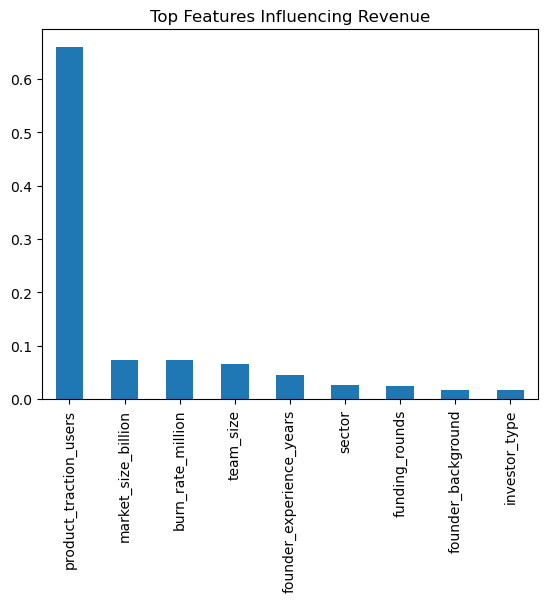

In [17]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features Influencing Revenue")
plt.show()